# Netflix Statistical Analysis

## Project Overview
This project analyzes Netflix movie data using statistical techniques such as:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Hypothesis Testing
- Correlation Analysis
- Regression Modeling

## Objective
To analyze Netflix movie durations and determine:
- Whether the average duration differs from 100 minutes
- The relationship between release year and duration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set(style="whitegrid")

## 📂 Load Dataset

In [2]:
df = pd.read_csv("../data/netflix_cleaned.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 🔍 Data Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8797 non-null   object
 1   type          8797 non-null   object
 2   title         8797 non-null   object
 3   director      8797 non-null   object
 4   cast          8797 non-null   object
 5   country       8797 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8797 non-null   int64 
 8   rating        8797 non-null   object
 9   duration      8797 non-null   object
 10  listed_in     8797 non-null   object
 11  description   8797 non-null   object
dtypes: int64(1), object(11)
memory usage: 824.8+ KB


In [4]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8797,8797,8797,8797,8797,8797,8797,8797.000000,8797,8797,8797,8797
unique,8797,2,8796,4529,7683,749,1714,NaN,18,221,513,8765
top,s8807,Movie,Consequences,Unknown,Not Available,United States,2020-01-01,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,2,2624,825,2812,110,NaN,3205,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.183472,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.822191,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## 🧹 Data Preparation

We prepare movie data and convert duration into numeric format.

In [5]:
# Filter only movies
df_movies = df[df['type'] == 'Movie'].copy()

# Convert duration (remove 'min')
df_movies['duration'] = df_movies['duration'].str.replace(' min', '', regex=False)

# Convert to numeric
df_movies['duration'] = pd.to_numeric(df_movies['duration'], errors='coerce')

# Drop missing values
df_movies = df_movies.dropna(subset=['duration'])

df_movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90.0,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91.0,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125.0,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104.0,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127.0,"Dramas, International Movies",After most of her family is murdered in a terr...


## Descriptive Statistics

In [6]:
df_movies['duration'].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

## 📈 Distribution of Movie Duration

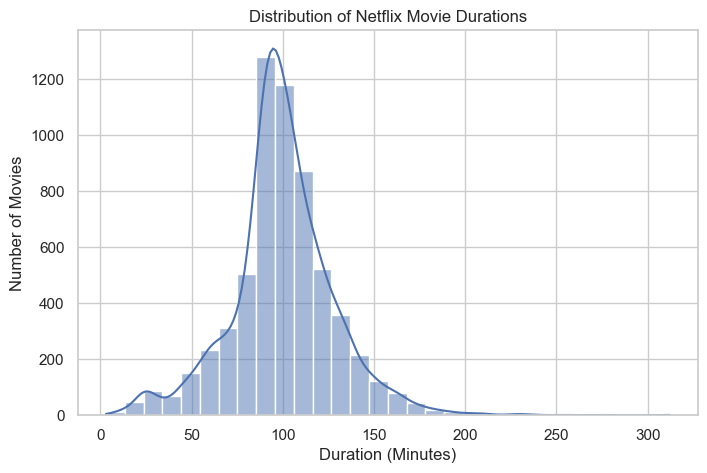

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df_movies['duration'], bins=30, kde=True)

plt.title("Distribution of Netflix Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.savefig("../images/movie_duration_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## 🧪 Hypothesis Testing

### Research Question:
Do Netflix movie durations differ from 100 minutes?

### Hypotheses:
- H0: Mean duration = 100 minutes  
- H1: Mean duration ≠ 100 minutes

In [8]:
duration = df_movies['duration']

t_stat, p_value = stats.ttest_1samp(duration, 100)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

T-statistic: -1.1699
P-value: 0.2421


## Interpretation

In [9]:
if p_value > 0.05:
    print("Fail to reject the null hypothesis.")
    print("➡️ Netflix movie durations are NOT significantly different from 100 minutes.")
else:
    print("Reject the null hypothesis.")
    print("➡️ Netflix movie durations ARE significantly different from 100 minutes.")

Fail to reject the null hypothesis.
➡️ Netflix movie durations are NOT significantly different from 100 minutes.


## Correlation Analysis

Check correlation between release year and movie duration.

In [10]:
correlation = df_movies[['release_year', 'duration']].corr()
correlation

,release_year,duration
release_year,1.000000,-0.206285
duration,-0.206285,1.000000


## 📉 Release Year vs Duration

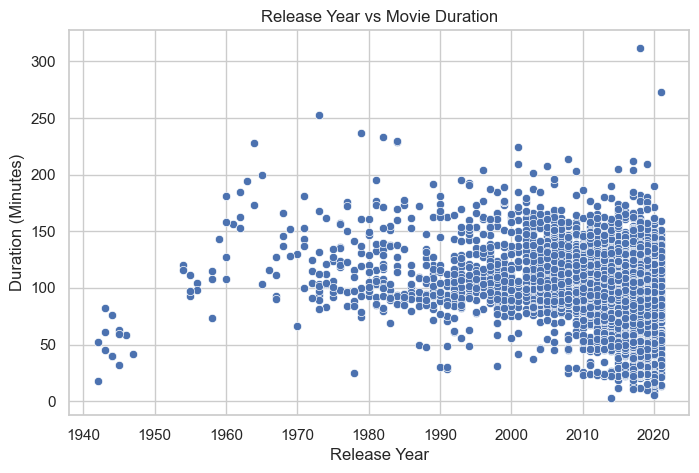

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='release_year', y='duration', data=df_movies)

plt.title("Release Year vs Movie Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")

plt.savefig("../images/duration_vs_year.png",dpi=300, bbox_inches='tight')
plt.show()

## 95% Confidence Interval for Mean Duration

In [12]:
mean = df_movies['duration'].mean()
std = df_movies['duration'].std()
n = len(df_movies)

ci_lower, ci_upper = stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n))

print("Confidence Interval:")
print(round(ci_lower,2), "to", round(ci_upper,2))

Confidence Interval:
98.87 to 100.29


## Interpretation

We are 95% confident that the true average duration of Netflix movies lies between:

 98.87 minutes and 100.29 minutes

## 📉 Regression Analysis

Model:
duration = β0 + β1 × release_year

In [13]:
model = smf.ols('duration ~ release_year', data=df_movies).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               duration   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     272.3
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           7.02e-60
Time:                        11:18:03   Log-Likelihood:                -29045.
No. Observations:                6128   AIC:                         5.809e+04
Df Residuals:                    6126   BIC:                         5.811e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1313.2183     73.552     17.854   

## 🔑 Key Findings

1. The average duration of Netflix movies is **99.58 minutes**, which is very close to the industry standard of 100 minutes.  

2. Most movies fall between **87 and 114 minutes**, indicating a standard feature-length format.  

3. A one-sample t-test shows **no statistically significant difference** from 100 minutes (**p = 0.242**).  

4. The correlation between release year and duration is **-0.206**, suggesting a **weak negative relationship** — newer movies tend to be slightly shorter.  

5. The 95% confidence interval for the true mean duration is **98.87 to 100.29 minutes**, confirming that the average duration is around 100 minutes.  

6. Regression analysis indicates that movie duration decreases by approximately **0.6 minutes per year**, although the relationship is weak (**R² = 0.043**).

## Business Insights

- Netflix maintains consistent movie durations aligned with industry standards  
- Slight decrease in duration suggests audience preference for shorter content  
- Content creators can optimize movie length (~90–110 minutes) for engagement  